# Extend LUH: Data Exploration & Validation

Explore the input data and verify the extension strategy for **REMIND-MAgPIE 3.5-4.11, SSP1 - Very Low Emissions**.

1. AFOLU rampdown trajectory (CSV) and gridded rate-of-change
2. BECCS scaling curve and biofuel crop fractions
3. Prototype extension and sanity checks

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'extend-luh'))
# Also handle running from notebooks/ dir
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from src import config as cfg
from src.data import (
    load_csv, filter_scenario, get_variable,
    beccs_scaling_factors, afolu_ramp,
    load_states, load_biof, state_2100, rates_2100,
)

# ── Scenario selector (change this to switch scenarios) ──
SCENARIO_KEY = "VL"      # "VL" | "H" | ...
sc = cfg.get_scenario(SCENARIO_KEY)
print(f"Scenario: {sc.key} — {sc.model} / {sc.scenario}")

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## 1. AFOLU + BECCS trajectories from CSV

The IAM CSV provides global and regional emissions out to 2500. Two variables drive the gridded extension:

- **AFOLU CO₂**: Emissions decline linearly to zero after 2100, setting the timeline over which we decay per-cell land-use change rates. We use this shape — not the absolute magnitude — because matching the emissions integral would require carbon-density fields from the ESM that we don't have.
- **BECCS**: Carbon Dioxide Removal via bioenergy with CCS rises after 2100, peaks, then falls back toward zero. We take the ratio relative to 2100 as a scaling factor for biofuel crop fractions. All REMIND regions share identical scaling factors, so a single global curve is sufficient.

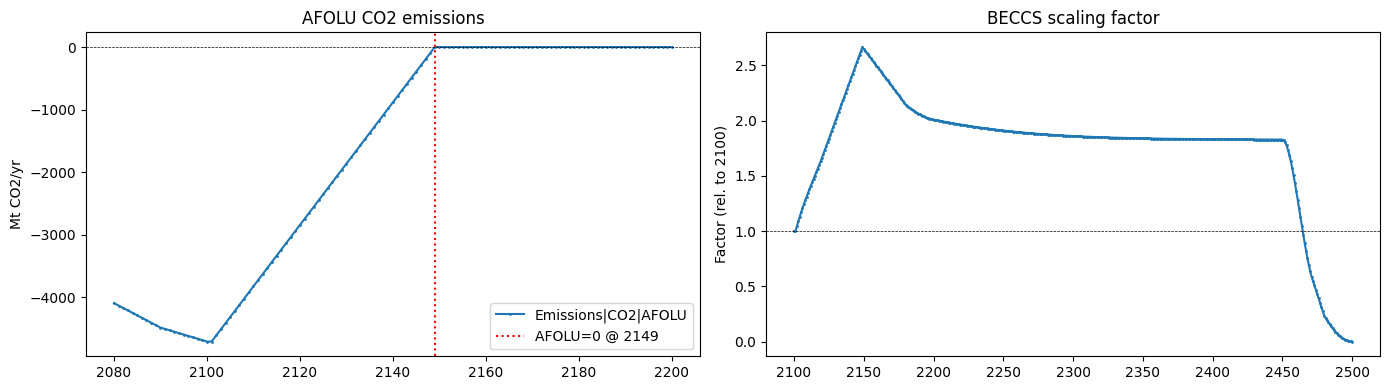

In [ ]:
df = load_csv()
sc_data = filter_scenario(df, scen=sc)

afolu = get_variable(sc_data, 'Emissions|CO2|AFOLU')
beccs = beccs_scaling_factors(sc_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
afolu.loc[2080:2200].plot(ax=ax, marker='.', ms=2)
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax.set_ylabel('Mt CO2/yr'); ax.set_title('AFOLU CO2 emissions'); ax.legend()

ax = axes[1]
beccs.loc[2100:2500].plot(ax=ax, marker='.', ms=2)
ax.axhline(1, color='k', ls='--', lw=0.5)
ax.set_ylabel('Factor (rel. to 2100)'); ax.set_title('BECCS scaling factor')

plt.tight_layout(); plt.show()

## 2. Gridded state rates at 2100

We compute per-cell rates of change as the difference between the last two input timesteps. These rates are constant over the final decade of the input (verified), so the last-year difference is a robust and representative baseline.

The table below shows global sums for each state variable at 2100, the net rate, and the estimated cumulative change under a linear ramp-to-zero (integral = rate × n_years / 2). This gives a first-order sense of how much land shifts before the ramp ends.

**Table columns:**
- **Variable** — one of the 13 state fractions (sum to 1.0 per land cell):
  `primf` / `secdf` (primary / secondary forest),
  `primn` / `secdn` (primary / secondary non-forest),
  `c3ann` / `c3nfx` / `c3per` / `c4ann` / `c4per` (crop types),
  `pastr` / `range` (managed pasture / rangeland),
  `urban`, `pltns` (plantations)
- **2100 sum** — global sum of the fraction field (larger = more area)
- **Rate/yr** — global net rate of change at 2100 (positive = expanding, negative = shrinking)
- **Δ by end** — estimated total shift by the time the ramp reaches zero
- **End est** — projected global sum after the ramp (2100 sum + Δ)

In [ ]:
ds_states = load_states(scen=sc)
vals = state_2100(ds_states, scen=sc)
rates = rates_2100(ds_states, scen=sc)

# Global budget table
print(f'{"Variable":10s} {"2100 sum":>12s} {"Rate/yr":>12s} {"Δ by 2149":>12s} {"2149 est":>12s}')
print('-' * 60)
for v in sc.state_vars:
    s = np.nansum(vals[v])
    r = np.nansum(rates[v])
    delta = r * 49 / 2  # integral of linear ramp
    print(f'{v:10s} {s:12.1f} {r:12.2f} {delta:12.1f} {s+delta:12.1f}')

Variable       2100 sum      Rate/yr    Δ by 2149     2149 est
------------------------------------------------------------
primf           33423.7       -17.27       -423.0      33000.7
secdf           45704.0        84.59       2072.5      47776.6
primn           46183.8        -3.35        -82.1      46101.8
secdn           35869.6        21.76        533.1      36402.8
c3ann            8995.3       -34.86       -854.0       8141.2
c3nfx            3938.4       -25.21       -617.7       3320.7
c3per            2923.5        -6.44       -157.7       2765.8
c4ann            3213.8       -10.00       -245.0       2968.8
c4per            2054.8         1.94         47.5       2102.3
pastr            8355.0        -3.80        -93.2       8261.8
range           34349.7        -1.72        -42.0      34307.6
urban            1641.1        -5.50       -134.9       1506.2
pltns            2640.2         1.33         32.5       2672.7


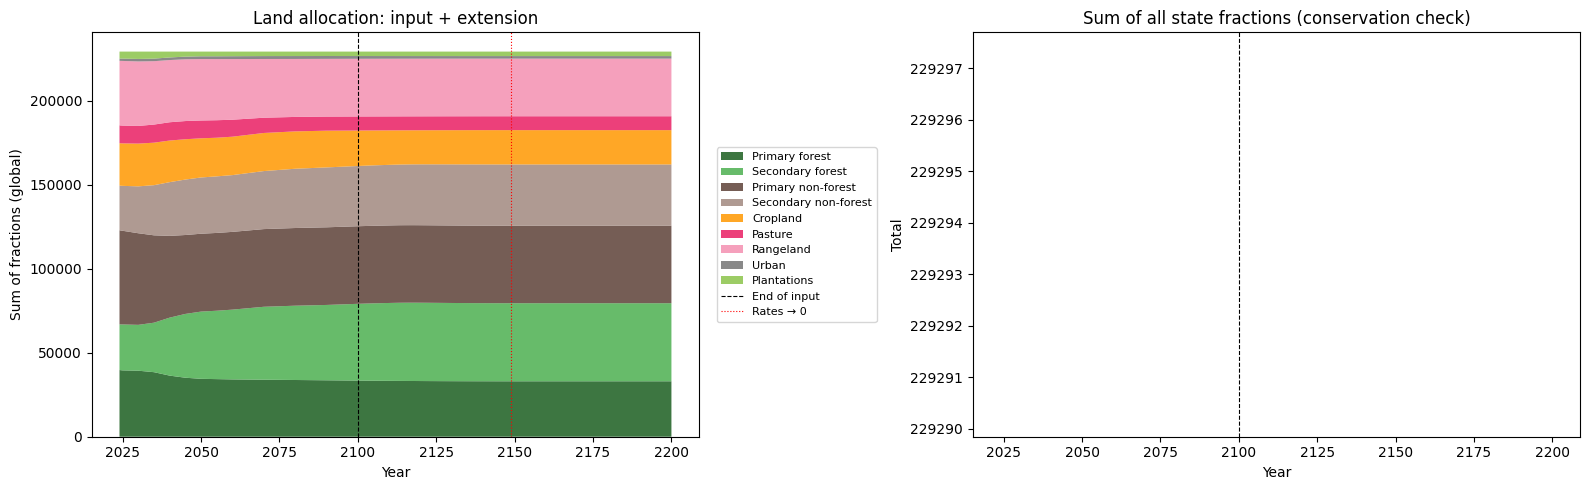

In [ ]:
# Stacked area plot: input period + extension
import importlib, src.extend
importlib.reload(src.extend)
from src.extend import extend_states as _extend_states

ext_yrs_area = np.arange(2101, 2201)
ext = _extend_states(vals, rates, ext_yrs_area,
                     state_vars=sc.state_vars, residual_var=sc.residual_var)

years_in = np.arange(2024, 2101)
all_years = np.concatenate([years_in, ext_yrs_area])

# Build groups dynamically from scenario state vars
_all_state = set(sc.state_vars)
_group_defs = [
    ('Primary forest',       ['primf']),
    ('Secondary forest',     ['secdf']),
    ('Forest',               ['forest']),
    ('Primary non-forest',   ['primn']),
    ('Secondary non-forest', ['secdn']),
    ('Cropland',             ['c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per']),
    ('Pasture',              ['pastr']),
    ('Rangeland',            ['range']),
    ('Urban',                ['urban']),
    ('Plantations',          ['pltns']),
]
groups = {}
for label, varlist in _group_defs:
    present = [v for v in varlist if v in _all_state]
    if present:
        groups[label] = present

_palette = {
    'Primary forest': '#1b5e20', 'Secondary forest': '#4caf50',
    'Forest': '#2e7d32',
    'Primary non-forest': '#5d4037', 'Secondary non-forest': '#a1887f',
    'Cropland': '#ff9800', 'Pasture': '#e91e63', 'Rangeland': '#f48fb1',
    'Urban': '#757575', 'Plantations': '#8bc34a',
}
colors = [_palette[l] for l in groups]

# Build timeseries: input from ds_states, extension from ext dict
group_sums = {}
for label, varlist in groups.items():
    hist_ts = np.array([
        sum(np.nansum(ds_states[v].isel(time=t).values) for v in varlist)
        for t in range(len(years_in))
    ])
    ext_ts = np.array([
        sum(np.nansum(ext[v][t]) for v in varlist)
        for t in range(len(ext_yrs_area))
    ])
    group_sums[label] = np.concatenate([hist_ts, ext_ts])

## 3. Rate ramp vs AFOLU trajectory

We overlay the linear rate multiplier (1 → 0) on the normalised AFOLU emissions curve. The multiplier is applied to every cell's rate of change each year, so the entire gridded field smoothly converges to a steady state.

We deliberately match the *shape and timing* of the AFOLU curve rather than the emissions integral. The integral depends on ESM-derived carbon densities that vary spatially and aren't available to us — so we treat the CSV as a temporal guide, not an absolute constraint.

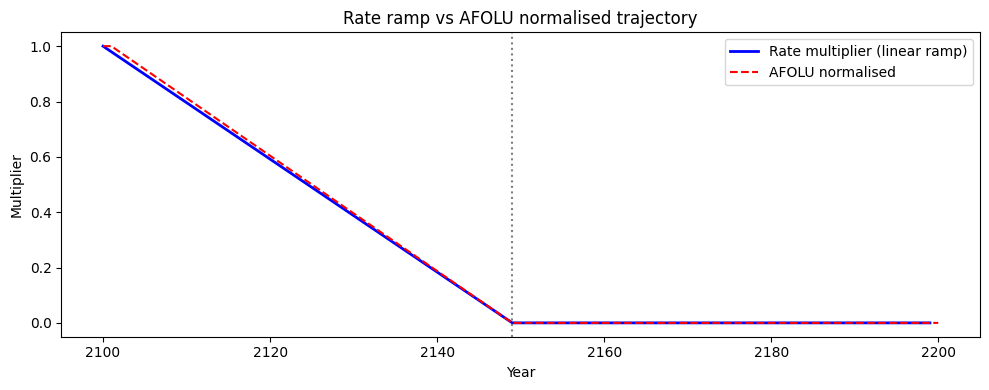

In [5]:
yrs = np.arange(2100, 2200)
ramp = afolu_ramp(yrs)

# Normalise AFOLU to same scale for overlay
afolu_norm = afolu.loc[2100:2200] / afolu.loc[2100]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yrs, ramp, 'b-', lw=2, label='Rate multiplier (linear ramp)')
ax.plot(afolu_norm.index, afolu_norm.values, 'r--', lw=1.5, label='AFOLU normalised')
ax.axvline(cfg.YR_AFOLU_ZERO, color='gray', ls=':')
ax.set_xlabel('Year'); ax.set_ylabel('Multiplier')
ax.set_title('Rate ramp vs AFOLU normalised trajectory')
ax.legend(); plt.tight_layout(); plt.show()

In [8]:
ds_states.close()